## Text Preprocessing & Lexical Exploration
Tokenisation, stop-word removal, word clouds and top bigrams per sentiment class.

Dataset shape: (22476, 13)

Columns:
['reviewer_id', 'store_name', 'category', 'store_address', 'latitude', 'longitude', 'rating_count_num', 'review_time', 'days_ago', 'review_clean', 'rating_num', 'sentiment', 'is_autotag']

Free-text reviews used for NLP: 22448

Sentiment distribution:
sentiment
Positive    9805
Negative    9454
Neutral     3189
Name: count, dtype: int64

Sentiment percentages:
sentiment
Positive    43.68
Negative    42.12
Neutral     14.21
Name: proportion, dtype: float64


PREPROCESSING TEST

Original : The food was good.
Processed: the food was good

Original : The food was not good.
Processed: the food was not good

Original : I didn't like the service.
Processed: did not like the service

Original : The service was excellent!
Processed: the service was excellent

Original : The service was never good.
Processed: the service was never good

Original : I can't recommend this place.
Processed: can not recommend this place

Original : The food wasn't bad.
Processed:

,review_clean,review_processed,sentiment
15505,Waited for 30 minutes for a burger. Had enough waiting and walked out. Left the receipt and table tag on the counter. That,waited for minutes for burger had enough waiting and walked out left the receipt and table tag the counter that,Negative
4712,Went to use the ladies room. Thank you for your clean restroom.,went use the ladies room thank you for your clean restroom,Positive
7970,Very quick service and really good food. My comfort food.,very quick service and really good food comfort food,Positive
15178,Like the big mac with extra sauce,like the big mac with extra sauce,Positive
5770,The large milkshake i ordered was the size of a medium. If i had known that i never would have ordered it. Disappointed,the large milkshake ordered was the size medium had known that never would have ordered disappointed,Negative
9901,There are a lot of people ~ moving fast,there are lot people moving fast,Positive
21815,"Great, as always",great always,Positive
14813,Not enough smiles,not enough smiles,Negative
2355,Friendly people and good location. Typical US interior,friendly people and good typical interior,Positive
9207,Love their deals,love their deals,Positive



Processed dataset saved to: text_reviews_processed.csv


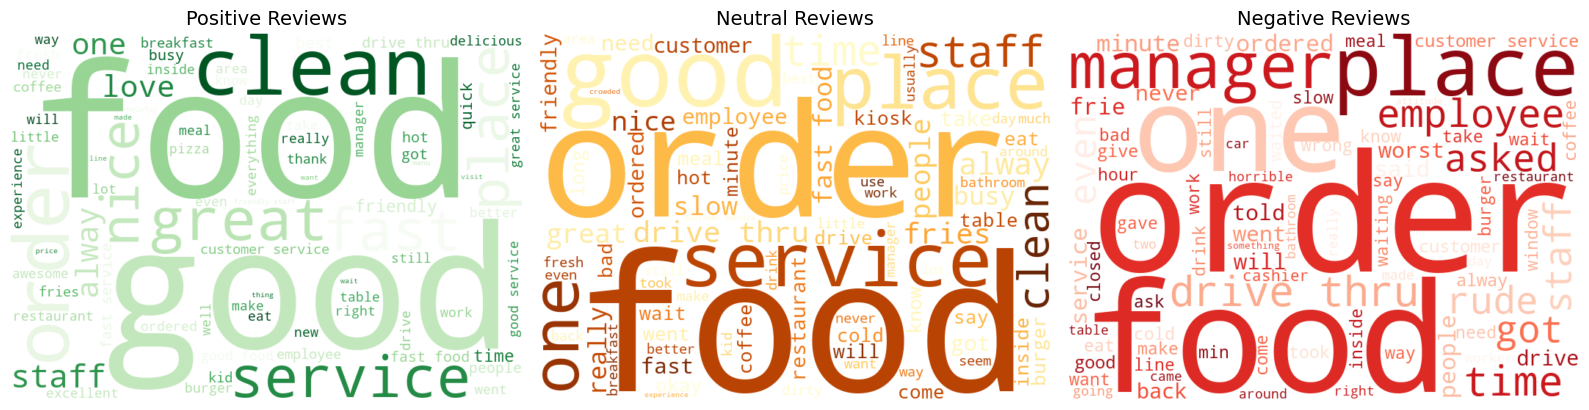

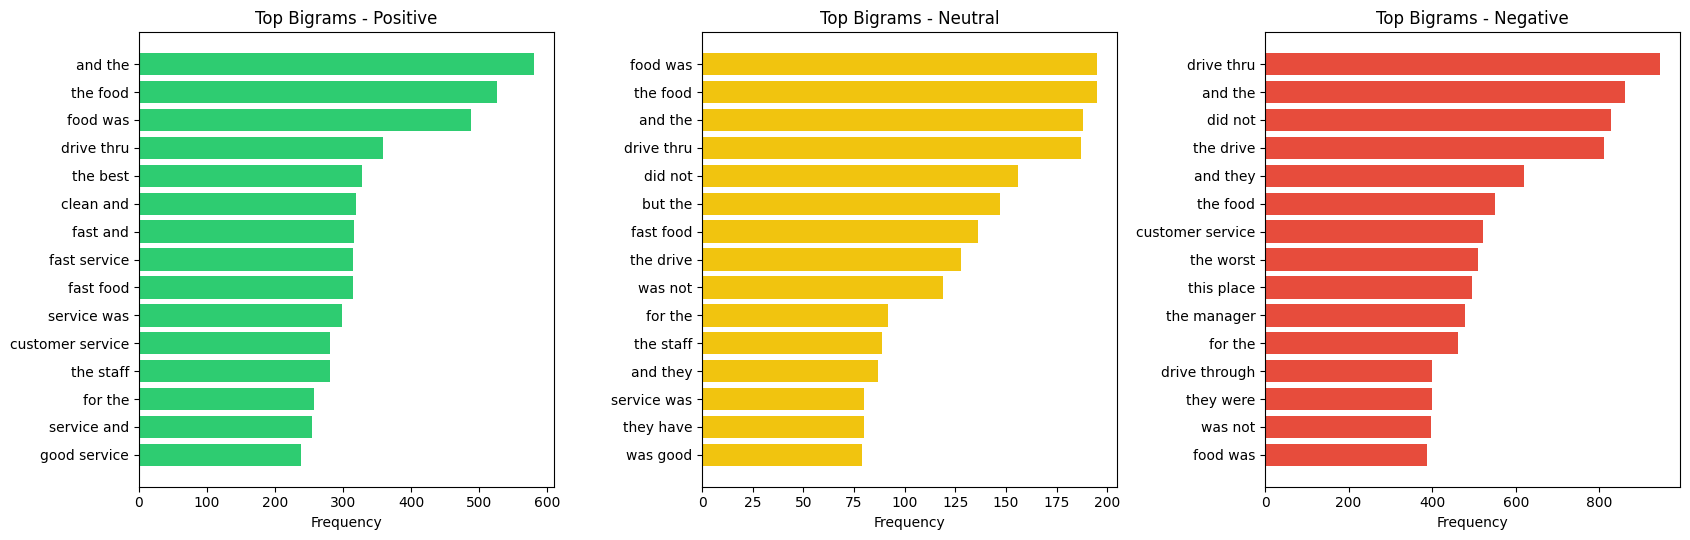



TEXT PREPROCESSING COMPLETED
Original dataset size       : 22476
Free-text reviews used      : 22366
Processed dataset saved as  : text_reviews_processed.csv
Word cloud saved as         : Figures/05_wordclouds.png
Bigram chart saved as       : Figures/06_top_bigrams.png


In [1]:
# ============================================================
# 03 - Text Preprocessing and Lexical Exploration
# ============================================================

# ------------------------------------------------------------
# 1. Import Libraries
# ------------------------------------------------------------

%matplotlib inline

import re
import os
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer


# ------------------------------------------------------------
# 2. Configuration
# ------------------------------------------------------------

FIG = "Figures"

# Create Figures directory if it does not exist
os.makedirs(FIG, exist_ok=True)


# ------------------------------------------------------------
# 3. Load Cleaned Dataset
# ------------------------------------------------------------

df = pd.read_csv("../data/cleaned_reviews.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())


# ------------------------------------------------------------
# 4. Select Genuine Free-text Reviews
# ------------------------------------------------------------

# Only genuine free-text reviews are used for NLP/text modelling
text_df = df[~df["is_autotag"]].copy()

print("\nFree-text reviews used for NLP:", len(text_df))

print("\nSentiment distribution:")
print(text_df["sentiment"].value_counts())

print("\nSentiment percentages:")
print(
    text_df["sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)


# ============================================================
# 5. Sentiment-Aware Text Preprocessing
# ============================================================

# ------------------------------------------------------------
# Domain-specific words that do not provide useful sentiment
# information for this particular dataset.
# ------------------------------------------------------------

DOMAIN_STOPWORDS = {
    "mcdonalds",
    "mcdonald",
    "mc",
    "donalds",
    "location",
    "store"
}


# ------------------------------------------------------------
# IMPORTANT:
# These words are intentionally preserved because they can
# change the sentiment of a sentence.
# ------------------------------------------------------------

NEGATION_WORDS = {
    "not",
    "no",
    "never",
    "neither",
    "nor",
    "cannot",
    "without"
}


# ------------------------------------------------------------
# Common contractions
# ------------------------------------------------------------

CONTRACTIONS = {
    "can't": "can not",
    "cannot": "can not",
    "won't": "will not",
    "wouldn't": "would not",
    "shouldn't": "should not",
    "couldn't": "could not",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "isn't": "is not",
    "wasn't": "was not",
    "weren't": "were not",
    "aren't": "are not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "i'm": "i am",
    "it's": "it is",
    "that's": "that is",
    "there's": "there is"
}


def preprocess(text):
    """
    Sentiment-aware text preprocessing.

    Steps:
    1. Convert text to lowercase
    2. Remove URLs
    3. Expand common contractions
    4. Remove non-alphabetic characters
    5. Preserve sentiment-related negation words
    6. Remove selected domain-specific words
    7. Remove very short tokens
    """

    # --------------------------------------------------------
    # Handle missing values
    # --------------------------------------------------------

    if pd.isna(text):
        return ""

    text = str(text).lower()


    # --------------------------------------------------------
    # Remove URLs
    # --------------------------------------------------------

    text = re.sub(
        r"http\S+|www\.\S+",
        " ",
        text
    )


    # --------------------------------------------------------
    # Expand contractions
    # --------------------------------------------------------

    for contraction, replacement in CONTRACTIONS.items():
        text = text.replace(
            contraction,
            replacement
        )


    # --------------------------------------------------------
    # Keep only alphabetic characters and spaces
    # --------------------------------------------------------

    text = re.sub(
        r"[^a-z\s]",
        " ",
        text
    )


    # --------------------------------------------------------
    # Remove extra whitespace
    # --------------------------------------------------------

    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()


    # --------------------------------------------------------
    # Token filtering
    # --------------------------------------------------------

    tokens = []

    for word in text.split():

        # Preserve sentiment-related negation words
        if word in NEGATION_WORDS:
            tokens.append(word)

        # Remove domain-specific words
        elif word in DOMAIN_STOPWORDS:
            continue

        # Remove very short words
        elif len(word) <= 2:
            continue

        else:
            tokens.append(word)


    return " ".join(tokens)


# ============================================================
# 6. Test the Preprocessing Function
# ============================================================

test_sentences = [
    "The food was good.",
    "The food was not good.",
    "I didn't like the service.",
    "The service was excellent!",
    "The service was never good.",
    "I can't recommend this place.",
    "The food wasn't bad."
]

print("\n")
print("=" * 80)
print("PREPROCESSING TEST")
print("=" * 80)

for sentence in test_sentences:

    processed = preprocess(sentence)

    print(f"\nOriginal : {sentence}")
    print(f"Processed: {processed}")

print("\n" + "=" * 80)


# ============================================================
# 7. Apply Preprocessing to the Dataset
# ============================================================

text_df["review_processed"] = (
    text_df["review_clean"]
    .fillna("")
    .apply(preprocess)
)


# ------------------------------------------------------------
# Remove reviews that became empty after preprocessing
# ------------------------------------------------------------

text_df = text_df[
    text_df["review_processed"]
    .str.strip()
    .str.len() > 0
].copy()


print(
    "\nReviews remaining after preprocessing:",
    len(text_df)
)


# ============================================================
# 8. Compare Original and Processed Reviews
# ============================================================

print("\n")
print("=" * 80)
print("ORIGINAL VS PROCESSED REVIEWS")
print("=" * 80)

comparison = text_df[
    [
        "review_clean",
        "review_processed",
        "sentiment"
    ]
].sample(
    min(15, len(text_df)),
    random_state=42
)

pd.set_option(
    "display.max_colwidth",
    200
)

display(comparison)


# ============================================================
# 9. Save Processed Dataset
# ============================================================

OUTPUT_FILE = "text_reviews_processed.csv"

text_df.to_csv(
    OUTPUT_FILE,
    index=False
)

print(
    f"\nProcessed dataset saved to: {OUTPUT_FILE}"
)


# ============================================================
# 10. Word Clouds by Sentiment
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5.5)
)

sentiments = [
    "Positive",
    "Neutral",
    "Negative"
]

colormaps = [
    "Greens",
    "YlOrBr",
    "Reds"
]

for ax, sentiment, cmap in zip(
    axes,
    sentiments,
    colormaps
):

    corpus = text_df.loc[
        text_df["sentiment"] == sentiment,
        "review_processed"
    ]

    text = " ".join(corpus)

    # Handle empty corpus safely
    if text.strip():

        wc = WordCloud(
            width=700,
            height=500,
            background_color="white",
            colormap=cmap,
            max_words=80
        ).generate(text)

        ax.imshow(
            wc,
            interpolation="bilinear"
        )

    ax.set_title(
        f"{sentiment} Reviews",
        fontsize=14
    )

    ax.axis("off")


plt.tight_layout()

plt.savefig(
    f"{FIG}/05_wordclouds.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. Top Bigrams by Sentiment
# ============================================================

def top_ngrams(
    corpus,
    n=15,
    ngram_range=(2, 2)
):
    """
    Find the most frequent n-grams in a corpus.

    No additional stopword removal is performed here because
    the corpus has already undergone sentiment-aware
    preprocessing.
    """

    vec = CountVectorizer(
        ngram_range=ngram_range,
        min_df=3
    )

    X = vec.fit_transform(corpus)

    freqs = X.sum(
        axis=0
    ).A1

    vocab = vec.get_feature_names_out()

    top = sorted(
        zip(vocab, freqs),
        key=lambda x: -x[1]
    )[:n]

    return pd.DataFrame(
        top,
        columns=[
            "ngram",
            "count"
        ]
    )


# ------------------------------------------------------------
# Plot top bigrams
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5.5)
)

plot_colors = [
    "#2ecc71",
    "#f1c40f",
    "#e74c3c"
]

for ax, sentiment, color in zip(
    axes,
    sentiments,
    plot_colors
):

    corpus = text_df.loc[
        text_df["sentiment"] == sentiment,
        "review_processed"
    ]

    top = top_ngrams(
        corpus,
        n=15,
        ngram_range=(2, 2)
    )

    ax.barh(
        top["ngram"][::-1],
        top["count"][::-1],
        color=color
    )

    ax.set_title(
        f"Top Bigrams - {sentiment}"
    )

    ax.set_xlabel(
        "Frequency"
    )


plt.tight_layout()

plt.savefig(
    f"{FIG}/06_top_bigrams.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 12. Final Summary
# ============================================================

print("\n")
print("=" * 80)
print("TEXT PREPROCESSING COMPLETED")
print("=" * 80)

print(
    f"Original dataset size       : {len(df)}"
)

print(
    f"Free-text reviews used      : {len(text_df)}"
)

print(
    f"Processed dataset saved as  : {OUTPUT_FILE}"
)

print(
    f"Word cloud saved as         : "
    f"{FIG}/05_wordclouds.png"
)

print(
    f"Bigram chart saved as       : "
    f"{FIG}/06_top_bigrams.png"
)

print("=" * 80)